# Analyzing river profiles in the Coastal Cordillera around the outlet of the Mataquito River

## Overview

**Purpose**: Analyze chi-elevation (χ-z) profiles for coastal streams near the Mataquito River outlet to characterize knickpoint migration and drainage reorganization in the Coastal Cordillera.

**Inputs**:
- `dem_utm30m.tif`, `fd_utm30m`, `area_utm30m` — external DEM data (not in repository)
- Outlet coordinates (UTM) for 6 coastal streams: Estero Curepto, Huenchullami River, Estero Los Cuervos, Estero Vichuquen, Estero San Pedro de Alcantara, Estero Paredones

**Outputs**:
- Chi vs. elevation plots for each coastal stream, with reference elevations marked

**Note**: Requires the external `TopoAnalysis` package and DEM data. The DEM file path must be configured in the `EXTERNAL DATA PATHS` cell below.

In [1]:
from TopoAnalysis import dem as d
import matplotlib.pylab as plt
from TopoAnalysis.plotting import plot_recursive_upstream_profiles
import numpy as np
import os
import pandas as pd

In [2]:
# Setting directory for files
# ── EXTERNAL DATA PATHS ──────────────────────────────────────────────
# These files are not included in the repository. Update the path below
# to point to your local DEM data directory containing area_utm30m,
# fd_utm30m, and dem_utm30m.tif.
DEM_DATA_DIR = '/path/to/30DEMwatersheddata'

new_directory_path = DEM_DATA_DIR  
os.chdir(new_directory_path)
print("New working directory:", os.getcwd())

New working directory: /Users/Glong1/Desktop/Andes/Andes_watersheds/MataquitoRiver/30DEMwatersheddata


In [5]:
area = d.Area.load('area_utm30m')
print('area loaded')
fd = d.FlowDirectionD8.load('fd_utm30m')
print('fd loaded')
elevation = d.Elevation.load('dem_utm30m.tif')
print('elevation loaded')

area loaded
fd loaded
elevation loaded


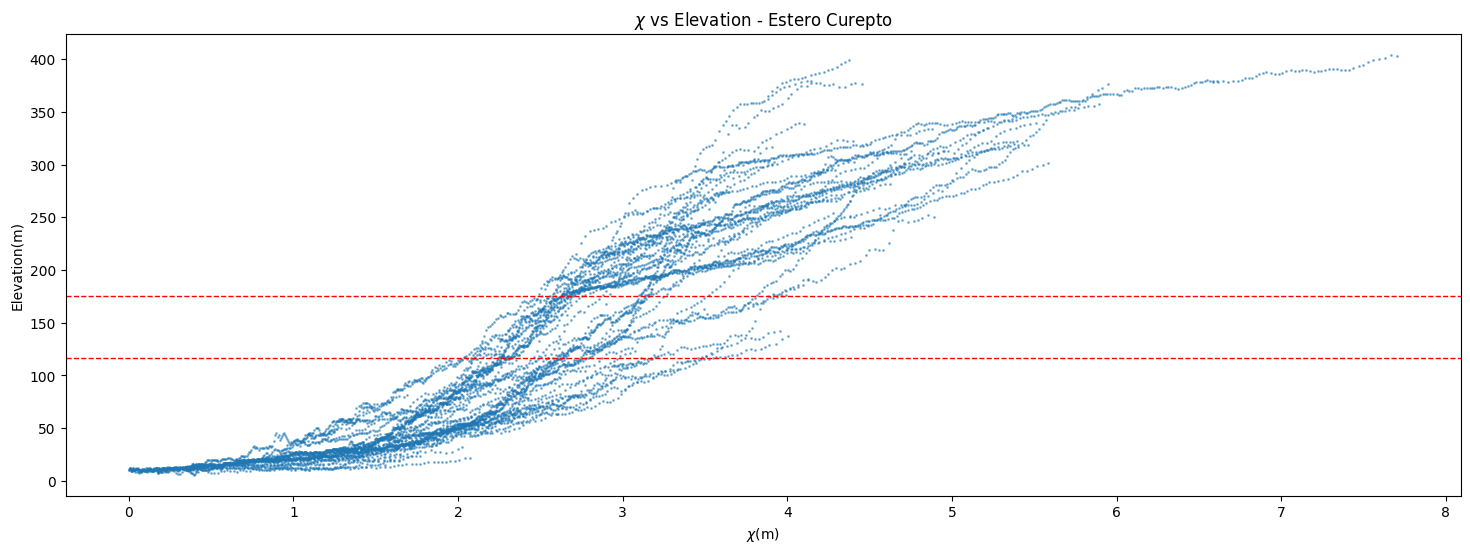

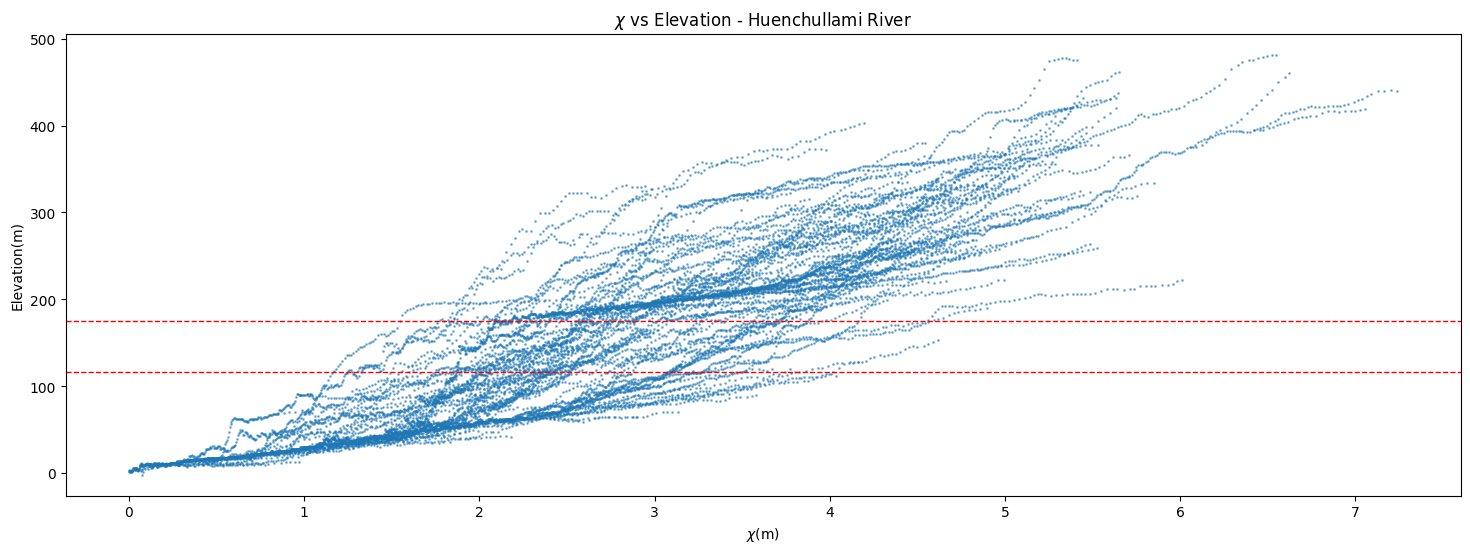

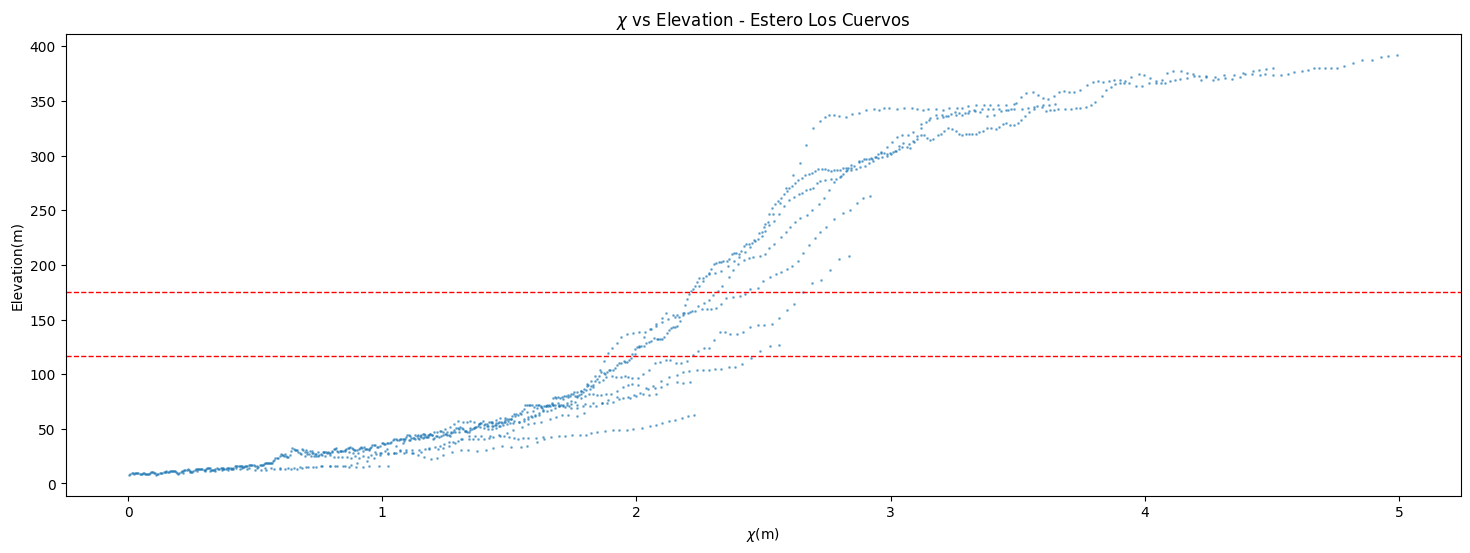

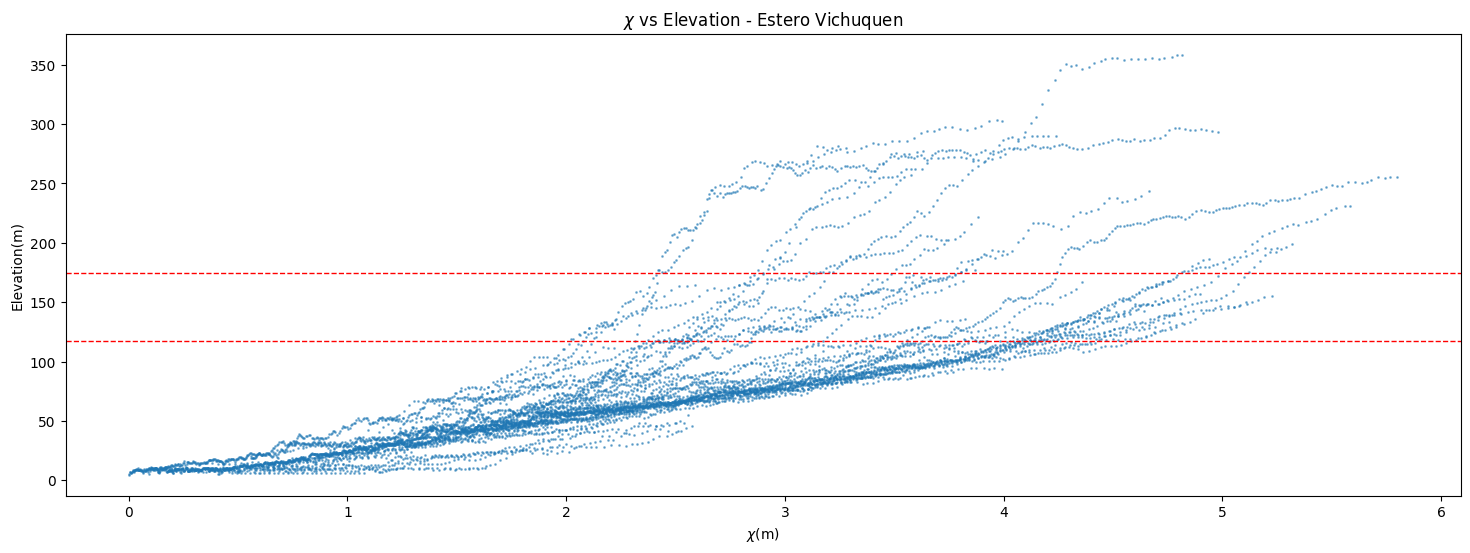

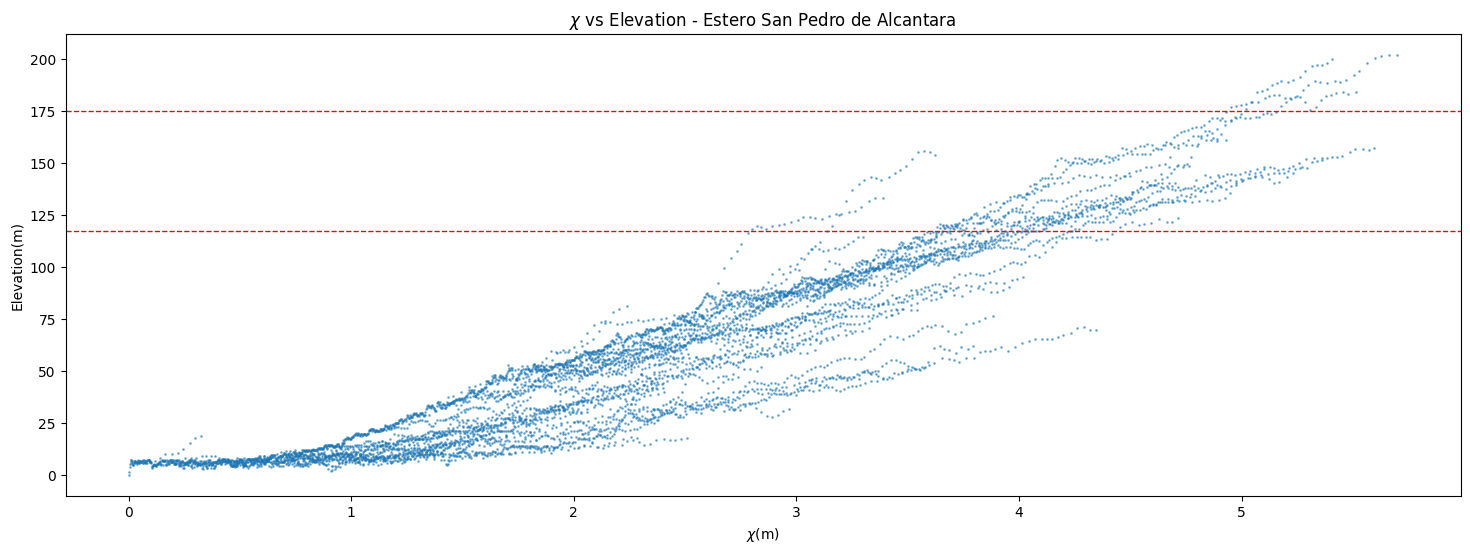

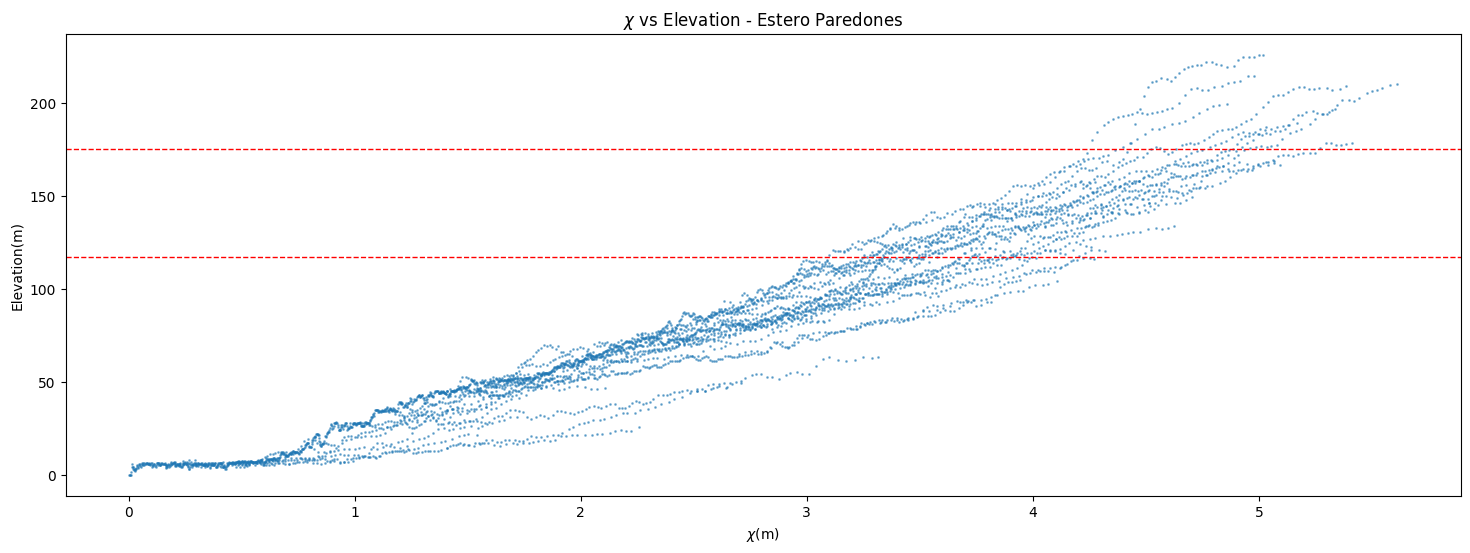

In [16]:
# Define your single outlet point
outlets = [(220105, 6117333),
           (207214, 6108725),
           (211126, 6118233),
           (223394, 6139757),
           (220209, 6157379),
           (221083, 6162719)
           
]
samples = [('Estero Curepto'),
           ('Huenchullami River'),
           ('Estero Los Cuervos'),
           ('Estero Vichuquen'),
           ('Estero San Pedro de Alcantara'),
           ('Estero Paredones')
]

for i, (outlet, sample) in enumerate(zip(outlets, samples)):
    chi_single = d.Chi(flow_direction=fd, area=area, theta=0.5, Ao=1, outlets=[outlet])
    
    chi_data = chi_single._griddata[chi_single._griddata > 0]
    elev_data = elevation._griddata[chi_single._griddata > 0]
    area_data = area._griddata[chi_single._griddata > 0]
    
    # Mask out areas less than 1 km^2
    mask_out = area_data >= 1e6  # 1 km^2 in m^2
    
    plt.figure(figsize=(18, 6))
    plt.scatter(chi_data[mask_out], elev_data[mask_out], s=1, alpha=0.5)
    plt.axhline(y=117, color='red', linestyle='--', linewidth=1)
    plt.axhline(y=175, color='red', linestyle='--', linewidth=1)
    plt.xlabel('$\\chi$(m)')
    plt.ylabel('Elevation(m)')
    plt.title(f'$\\chi$ vs Elevation - {sample}')
    #plt.savefig(f'Figures/chi_elevation_plot_{sample}.png', bbox_inches='tight', pad_inches=0.1)  # Unique filename for each
    plt.show()